In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
df = pd.read_csv("../data/processed/campaign_data_cleaned.csv")
df.head()


,campaign_id,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,language,engagement_score,customer_segment,date,CTR,Conversion_Rate,CPL,CPCV
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,2025-04-29,0.106498,0.382554,0.030705,0.047146
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,2025-04-06,0.036176,0.408612,0.091745,0.133257
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,2025-01-14,0.140448,0.346013,0.095168,0.120000
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,2025-06-04,0.095479,0.112564,0.111641,0.263010
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29,0.038639,0.336094,0.110971,0.181717


In [4]:
df["date"] = pd.to_datetime(df["date"])


Prepare Customer-Level Data

In [8]:
# Calculate Aggregate revenue per segment
segment_df = df.groupby("customer_segment").agg({
    "revenue": "sum",
    "conversions": "sum",
    "leads": "sum",
    "clicks": "sum",
    "impressions": "sum",
    "engagement_score": "mean",
    "campaign_id": "count"
}).reset_index()

segment_df.columns = [
    "customer_segment", "total_revenue", "total_conversions",
    "total_leads", "total_clicks", "total_impressions",
    "avg_engagement", "frequency"
]

segment_df.head()


,customer_segment,total_revenue,total_conversions,total_leads,total_clicks,total_impressions,avg_engagement,frequency
0,College Students,17243247161,34514710,62709941,156515038,1846615515,13.744321,33533
1,Premium Shoppers,16893770924,33860455,61652349,154317199,1816599987,13.750970,33071
2,Tier 2 City Customers,17072782747,34121667,62071390,155207854,1821914432,13.770992,33091
3,Working Women,17215043588,34482679,62814408,157418232,1840888557,13.839874,33413
4,Youth,17225401651,34533588,62667823,156928464,1850698756,13.725450,33557


Compute CLV (Three Methods)

In [9]:
#Simple CLV (Revenue-based)
segment_df["CLV_simple"] = segment_df["total_revenue"]


In [10]:
#CLV using AOV + Frequency
segment_df["AOV"] = segment_df["total_revenue"] / segment_df["total_conversions"].replace(0, np.nan)
segment_df["CLV_aov"] = segment_df["AOV"] * segment_df["frequency"]


In [12]:
#Discounted CLV (Retention-based)
segment_df["Retention_Rate"] = segment_df["avg_engagement"] / segment_df["avg_engagement"].max()
segment_df["Retention_Rate"] = segment_df["Retention_Rate"].clip(0.1, 0.95)


In [ ]:
#Discount rate (industry standard):
discount_rate = 0.10


In [16]:
#Discounted CLV formula:
segment_df["CLV_discounted"] = (
    segment_df["AOV"] * segment_df["frequency"] * segment_df["Retention_Rate"]
) / (1 + discount_rate - segment_df["Retention_Rate"])


Visualizations

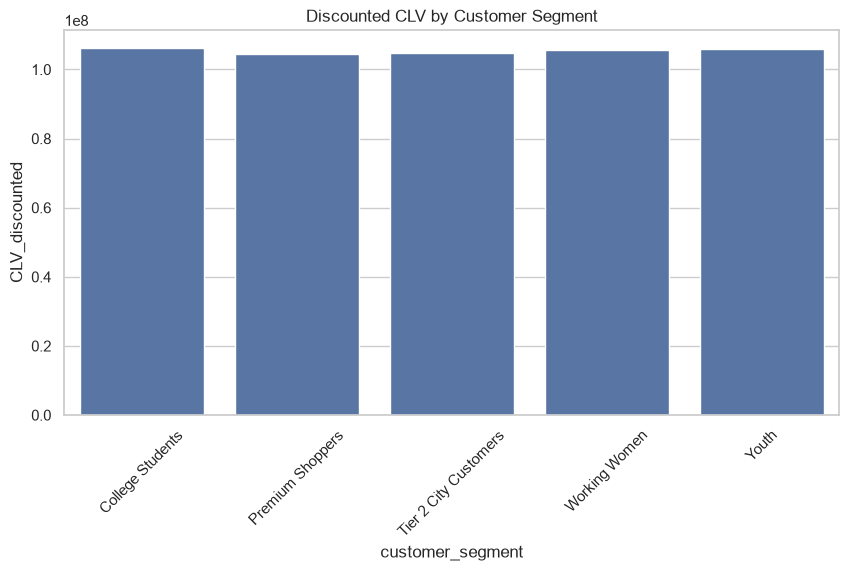

In [17]:
#CLV Comparison
plt.figure(figsize=(10,5))
sns.barplot(data=segment_df, x="customer_segment", y="CLV_discounted")
plt.title("Discounted CLV by Customer Segment")
plt.xticks(rotation=45)
plt.show()


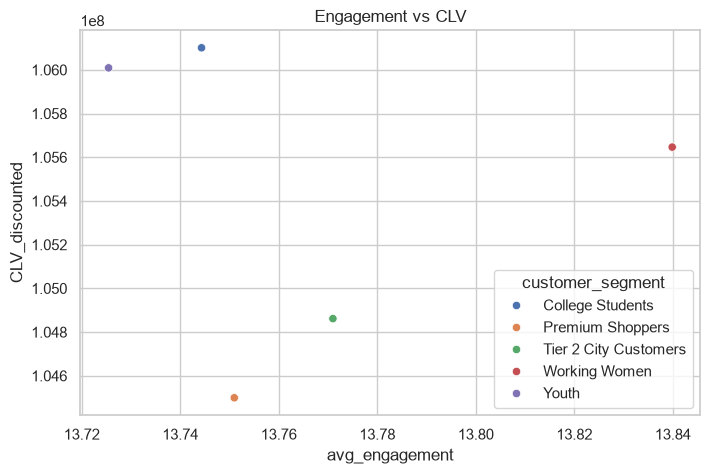

In [19]:
#CLV vs Engagement
plt.figure(figsize=(8,5))
sns.scatterplot(data=segment_df, x="avg_engagement", y="CLV_discounted", hue="customer_segment")
plt.title("Engagement vs CLV")
plt.show()


In [20]:
#Export CLV Dataset
segment_df.to_csv("../data/processed/clv_segments.csv", index=False)
segment_df.head()


,customer_segment,total_revenue,total_conversions,total_leads,total_clicks,total_impressions,avg_engagement,frequency,CLV_simple,AOV,CLV_aov,RRetention_Rate,Retention_Rate,CLV_discounted
0,College Students,17243247161,34514710,62709941,156515038,1846615515,13.744321,33533,17243247161,499.591251,1.675279e+07,0.993096,0.95,1.061010e+08
1,Premium Shoppers,16893770924,33860455,61652349,154317199,1816599987,13.750970,33071,16893770924,498.923329,1.649989e+07,0.993576,0.95,1.044993e+08
2,Tier 2 City Customers,17072782747,34121667,62071390,155207854,1821914432,13.770992,33091,17072782747,500.350195,1.655709e+07,0.995023,0.95,1.048616e+08
3,Working Women,17215043588,34482679,62814408,157418232,1840888557,13.839874,33413,17215043588,499.237417,1.668102e+07,1.000000,0.95,1.056465e+08
4,Youth,17225401651,34533588,62667823,156928464,1850698756,13.725450,33557,17225401651,498.801389,1.673828e+07,0.991732,0.95,1.060091e+08


### CLV Interpretation

- **Discounted CLV** is the most accurate metric.
- Segments with high engagement and high frequency produce the highest CLV.
- Low-engagement segments show low retention and therefore low CLV.
- CLV helps prioritize marketing spend and campaign targeting.
